In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
# frequency^2 v Tension
f = np.array([62.676, 85.081, 104.979, 120.806, 133.430])
f2 = f**2
s = np.array([1,2,3,4,5])
T = 0.26 * 0.9970 * s

# frequency v 1/length
l = np.array([50, 45, 40, 35, 30, 25, 20, 15]) * 1e-2
invl = 1/l
fres = np.array([111.888, 111.973, 112.033, 112.002, 112.004, 112.129, 112.075, 112.060])

# Error propagation
errinvl = 0.0005/(l**2) # delta 1/L / 1/L = delta L / L
errT = s * 0.26 * 0.00005 # delta T = sz * delta W
errf2 = 2 * f * 1 # y = f^2 -> delta y = |d/df f^2| * delta f

print(f2, T)
print(invl, fres)

print(errinvl, errT, errf2)

[ 3928.280976  7238.776561 11020.590441 14594.089636 17803.5649  ] [0.25922 0.51844 0.77766 1.03688 1.2961 ]
[2.         2.22222222 2.5        2.85714286 3.33333333 4.
 5.         6.66666667] [111.888 111.973 112.033 112.002 112.004 112.129 112.075 112.06 ]
[0.002      0.00246914 0.003125   0.00408163 0.00555556 0.008
 0.0125     0.02222222] [1.3e-05 2.6e-05 3.9e-05 5.2e-05 6.5e-05] [125.352 170.162 209.958 241.612 266.86 ]


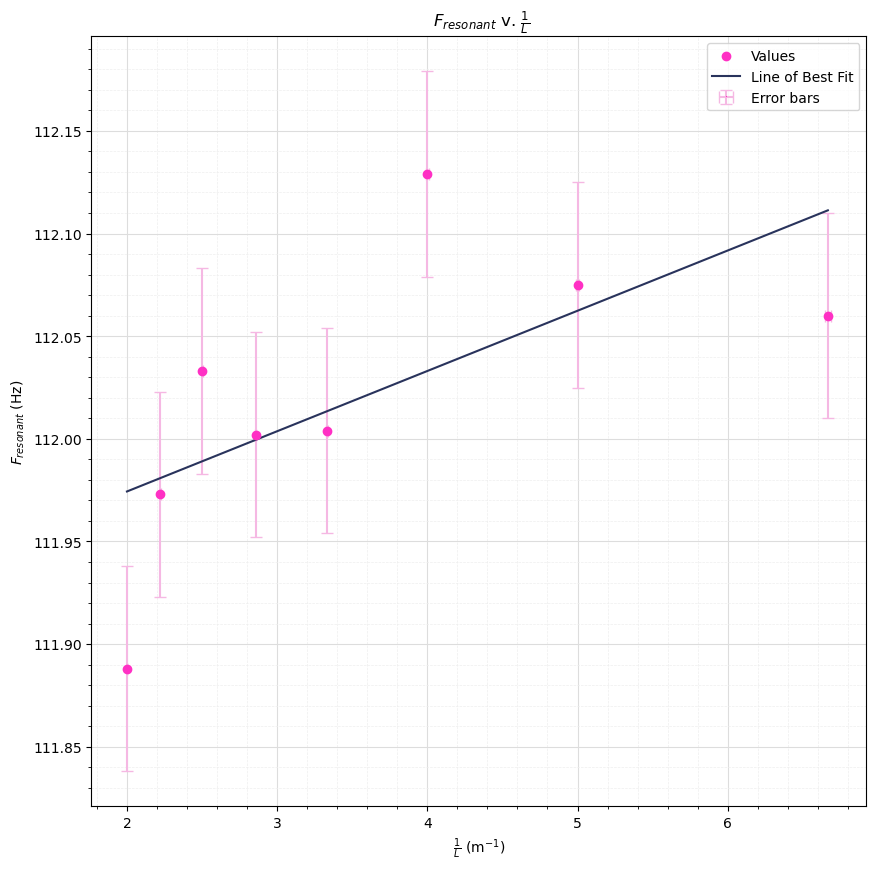

0.029347725577688066


In [49]:
slope, intercept = np.polyfit(invl, fres,1)

plt.figure(figsize=(10,10))

# Plot
plt.scatter(invl, fres, color="#ff30c4", label="Values", zorder=5)

# Error
plt.errorbar(invl, fres, xerr=errinvl, yerr=0.05, fmt=",", ecolor="#f5b8e3", color="#ff30c4", capsize=4, barsabove=True, zorder=3, label="Error bars")

#Grid
plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD")
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--")

#Line of Best Fit
plt.plot(np.unique(invl), np.poly1d(np.polyfit(invl, fres, 1))(np.unique(invl)), color = "#29335C", label="Line of Best Fit", zorder=4)

# Labels
plt.title(r" $F_{resonant}$ v. $\frac{1}{L}$")
plt.ylabel(r"$F_{resonant}$ (Hz)")
plt.xlabel(r"$\frac{1}{L}$ $(\text{m}^{-1})$")
plt.legend()

plt.show()

print(np.abs(slope))

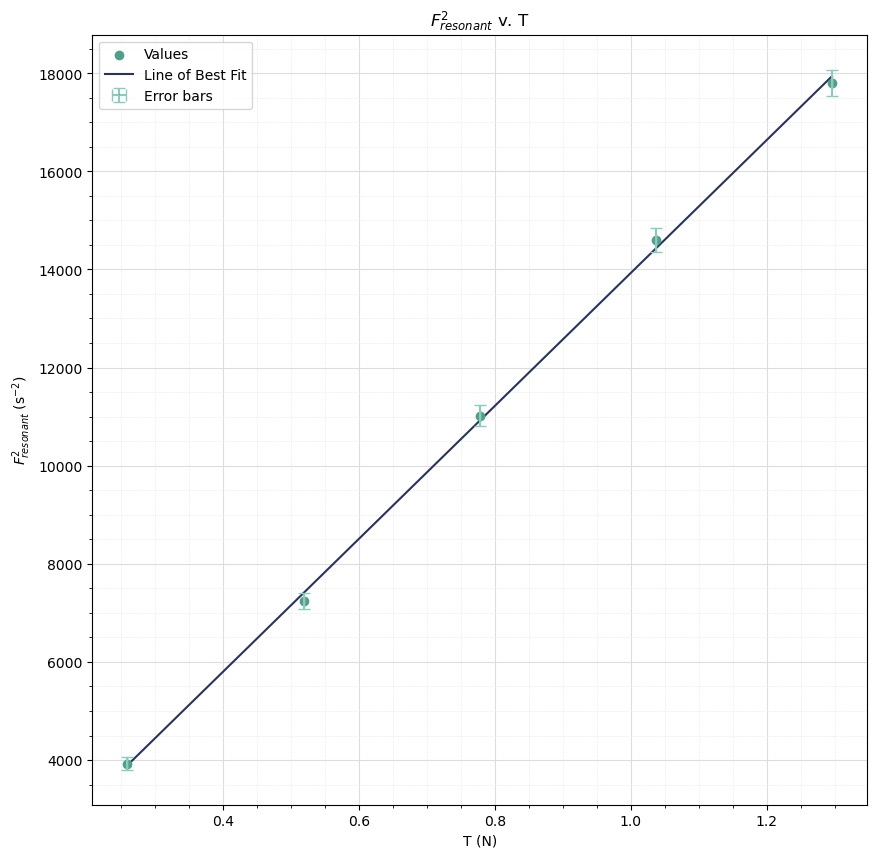

13542.890565157008


In [51]:
slope, intercept = np.polyfit(T, f2, 1)

plt.figure(figsize=(10,10))

# Plot
plt.scatter(T, f2, color="#519E8A", label="Values", zorder=4)

# Error
plt.errorbar(T, f2, xerr=errT, yerr=errf2, fmt=",", ecolor="#89ccba", color="#519E8A", capsize=4, barsabove=True, zorder=5, label="Error bars")

#Grid
plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD")
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--")

#Line of Best Fit
plt.plot(np.unique(T), np.poly1d(np.polyfit(T, f2, 1))(np.unique(T)), color = "#29335C", label="Line of Best Fit", zorder=3)

# Labels
plt.title(r"$F_{resonant}^2$ v. T")
plt.ylabel(r"$F_{resonant}^2$ (s$^{-2}$)")
plt.xlabel("T (N)")
plt.legend()

plt.show()

print(np.abs(slope))